# Network Intrusion Detection with Logistic Regression

**Goal:** show how a basic ML model can flag anomalous network activity using the NSL-KDD benchmark dataset.


In [9]:
import sys
sys.path.append("..")  # so we can import the src package from the notebooks/ folder

from src.data_loader import download_data, load_data
from src.preprocessing import prepare_features
from src.model import train_model, predict
from src.evaluate import evaluate, print_report
from src.neural_net import train_mlp, predict_mlp

## 1. Download and load the data

NSL-KDD has 41 features per network connection (protocol type, byte counts, error rates, etc.) plus a label. We simplify them to a binary label: normal vs. attack.

In [10]:
download_data(data_dir="../data")
train, test = load_data(data_dir="../data")

print("Training rows:", len(train))
print("Test rows:", len(test))
train.head(20)

Training rows: 125973
Test rows: 22544


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty,is_attack
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20,0
1,0,udp,other,SF,146,0,0,0,0,0,...,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15,0
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19,1
3,0,tcp,http,SF,232,8153,0,0,0,0,...,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21,0
4,0,tcp,http,SF,199,420,0,0,0,0,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21,0
5,0,tcp,private,REJ,0,0,0,0,0,0,...,0.07,0.00,0.00,0.00,0.00,1.00,1.00,neptune,21,1
6,0,tcp,private,S0,0,0,0,0,0,0,...,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,21,1
7,0,tcp,private,S0,0,0,0,0,0,0,...,0.07,0.00,0.00,1.00,1.00,0.00,0.00,neptune,21,1
8,0,tcp,remote_job,S0,0,0,0,0,0,0,...,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,21,1
9,0,tcp,private,S0,0,0,0,0,0,0,...,0.06,0.00,0.00,1.00,1.00,0.00,0.00,neptune,21,1


## 2. Prepare features

This encodes the text columns (`protocol_type`, `service`, `flag`) into numbers and scales everything, since logistic regression needs numeric, comparably-sized inputs.

In [11]:
X_train, X_test, y_train, y_test, scaler = prepare_features(train, test)

print("Feature matrix shape:", X_train.shape)

Feature matrix shape: (125973, 41)


## 3. Train the model

In [12]:
model = train_model(X_train, y_train)
print("Model trained")

Model trained


## 4. Evaluate

We look at accuracy, precision, and recall rather than just accuracy, since missing an attack is usually worse than a false alarm.

In [13]:
y_pred = predict(model, X_test)
print_report(y_test, y_pred)

Accuracy:  0.7539
Precision: 0.9252
Recall:    0.6175

Confusion matrix (rows=actual, cols=predicted):
[[9070  641]
 [4908 7925]]

              precision    recall  f1-score   support

      normal       0.65      0.93      0.77      9711
      attack       0.93      0.62      0.74     12833

    accuracy                           0.75     22544
   macro avg       0.79      0.78      0.75     22544
weighted avg       0.81      0.75      0.75     22544



## 5. Create a neural network to compare

I made two single hidden layer neural network to compare against the linear regression model. These are signifigantly heavier than the linear regresion.

In [14]:
#32 nodes with 42 random states
mlp_model = train_mlp(X_train, y_train)
#128 nodes with 64 random states
mlp_model_2 = train_mlp(X_train, y_train, 128, 64)



## 6. Compare the new models

           Logistic Regression  Neural Net (default 32)  Neural Net (128, 64)
Accuracy              0.753859                 0.789523              0.782692
Precision             0.925169                 0.969250              0.970247
Recall                0.617549                 0.650900              0.637809


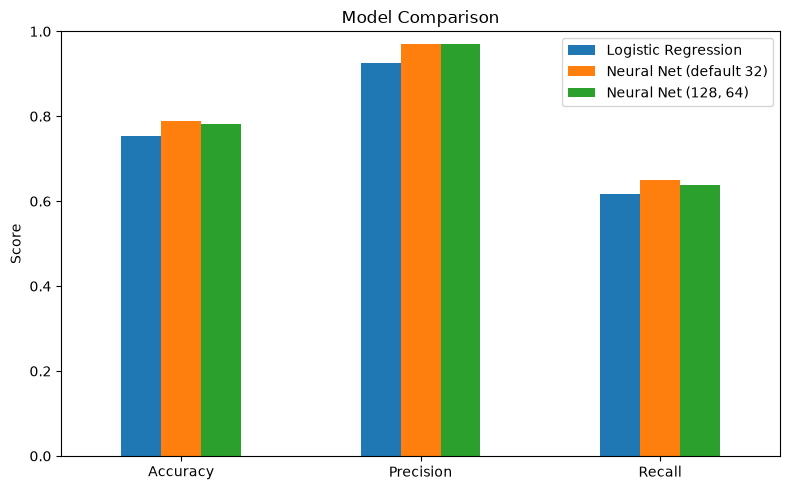

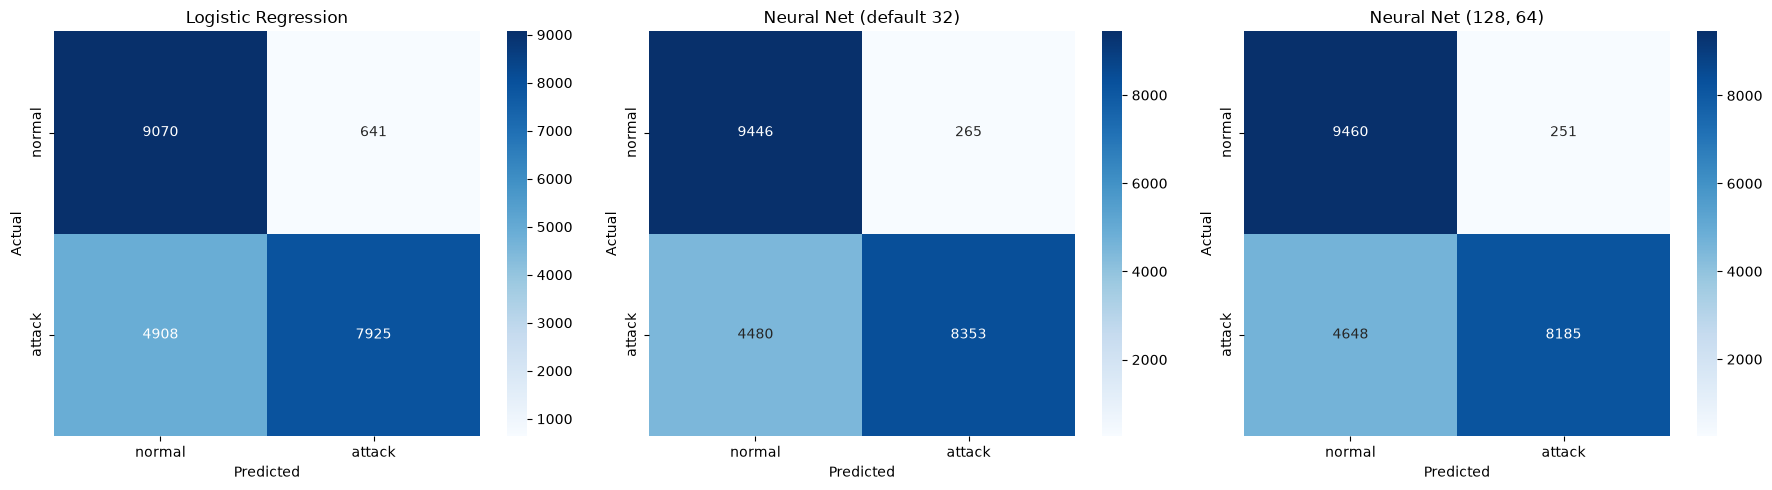

In [15]:
from src.compare import compare_models, plot_comparison

lr_model = model

models = {
    "Logistic Regression": lr_model,
    "Neural Net (default 32)": mlp_model,
    "Neural Net (128, 64)": mlp_model_2,
}

results_df, confusion_matrices = compare_models(models, X_test, y_test)
print(results_df)
plot_comparison(results_df, confusion_matrices)

## Evaluation

It was interesting to see how a Neural Net of 32 nodes was argueably the best model out of them all.